# Olist E-Commerce — Three ML Models

This notebook builds three machine learning models on the Olist Brazilian e-commerce dataset:

1. **Review Score Prediction** — will a customer leave a good (4–5) or bad (1–3) review?
2. **Delivery Delay Prediction** — will an order arrive late (after the estimated delivery date)?
3. **Daily Orders Forecasting** — predict the number of orders placed per day (time series regression).

Each section follows the same flow: build a feature table → train/test split → train model(s) → evaluate → interpret.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

pd.set_option('display.max_columns', 50)

In [2]:
# Load all cleaned tables
customers = pd.read_csv('customers_cleaned.csv')
order_items = pd.read_csv('order_items_cleaned.csv')
order_payments = pd.read_csv('order_payments_cleaned.csv')
orders = pd.read_csv('orders_cleaned.csv')
products = pd.read_csv('products_cleaned.csv')
reviews = pd.read_csv('reviews_cleaned.csv')
sellers = pd.read_csv('sellers_cleaned.csv')

# Parse all date columns
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')

print('orders:', orders.shape)
print('order_items:', order_items.shape)
print('order_payments:', order_payments.shape)
print('reviews:', reviews.shape)
print('products:', products.shape)
print('customers:', customers.shape)
print('sellers:', sellers.shape)

orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 10)
customers: (99441, 5)
sellers: (3095, 4)


## 1. Build a Master Order-Level Feature Table

Most of the signal for both the review-score and delivery-delay models lives at the **order level**, so we
aggregate `order_items` and `order_payments` up to one row per `order_id`, then join in `orders`, `customers`,
`products` (for the item-level info we take a size-weighted / first-item view), and `sellers`.


In [3]:
# --- Aggregate order_items to order level ---
items_agg = order_items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    n_sellers=('seller_id', 'nunique'),
    n_products=('product_id', 'nunique'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    avg_item_price=('price', 'mean'),
).reset_index()

# Take the product of the FIRST item in each order as a representative product profile
first_item = order_items.sort_values(['order_id', 'order_item_id']).groupby('order_id').first().reset_index()
first_item = first_item.merge(products, on='product_id', how='left')
first_item = first_item.merge(sellers, on='seller_id', how='left')

product_cols = ['order_id', 'product_category_name_english', 'product_weight_g',
                 'product_length_cm', 'product_height_cm', 'product_width_cm',
                 'product_photos_qty', 'seller_state']
items_agg = items_agg.merge(first_item[product_cols], on='order_id', how='left')

# --- Aggregate payments to order level ---
pay_agg = order_payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    n_payment_methods=('payment_type', 'nunique'),
    max_installments=('payment_installments', 'max'),
).reset_index()

# Most common payment type per order
top_payment_type = (order_payments.groupby(['order_id', 'payment_type'])['payment_value']
                     .sum().reset_index()
                     .sort_values('payment_value', ascending=False)
                     .drop_duplicates('order_id')[['order_id', 'payment_type']])
pay_agg = pay_agg.merge(top_payment_type, on='order_id', how='left')

print('items_agg:', items_agg.shape)
print('pay_agg:', pay_agg.shape)

items_agg: (98666, 14)
pay_agg: (99440, 5)


In [4]:
# --- Build master table ---
master = orders.merge(customers, on='customer_id', how='left')
master = master.merge(items_agg, on='order_id', how='left')
master = master.merge(pay_agg, on='order_id', how='left')

# Delivery timing features
master['delivery_days'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
master['estimated_delivery_days'] = (master['order_estimated_delivery_date'] - master['order_purchase_timestamp']).dt.days
master['delay_days'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days
master['is_late'] = (master['delay_days'] > 0).astype('Int64')
master['approval_hours'] = (master['order_approved_at'] - master['order_purchase_timestamp']).dt.total_seconds() / 3600
master['shipping_days'] = (master['order_delivered_carrier_date'] - master['order_approved_at']).dt.days

# Purchase-time calendar features (known at order time -> safe for the delay model too)
master['purchase_dow'] = master['order_purchase_timestamp'].dt.dayofweek
master['purchase_month'] = master['order_purchase_timestamp'].dt.month
master['purchase_hour'] = master['order_purchase_timestamp'].dt.hour
master['is_weekend_purchase'] = master['purchase_dow'].isin([5, 6]).astype(int)
master['same_state'] = (master['customer_state'] == master['seller_state']).astype(int)

# Attach review score (one review per order, take the latest if duplicates exist)
rev = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')
master = master.merge(rev[['order_id', 'review_score']], on='order_id', how='left')

print('master shape:', master.shape)
master.head(3)

master shape: (99441, 41)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_items,n_sellers,n_products,total_price,total_freight,avg_item_price,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_photos_qty,seller_state,total_payment_value,n_payment_methods,max_installments,payment_type,delivery_days,estimated_delivery_days,delay_days,is_late,approval_hours,shipping_days,purchase_dow,purchase_month,purchase_hour,is_weekend_purchase,same_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,29.99,housewares,500.0,19.0,8.0,13.0,4.0,SP,38.71,2.0,1.0,voucher,8.0,15,-8.0,0,0.178333,2.0,0,10,10,0,1,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,118.70,perfumery,400.0,19.0,13.0,19.0,1.0,SP,141.46,1.0,1.0,boleto,13.0,19,-6.0,0,30.713889,0.0,1,7,20,0,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,159.90,auto,420.0,24.0,19.0,21.0,1.0,SP,179.12,1.0,3.0,credit_card,9.0,26,-18.0,0,0.276111,0.0,2,8,8,0,0,5.0


## 2. Model 1 — Review Score Prediction

**Business question:** given the order and delivery characteristics, will the customer leave a *good* review
(score 4–5) or a *bad* review (score 1–3)?

We only use orders that are `delivered` and have a review, and we deliberately **exclude** any text/comment
fields (we're predicting from logistics & product data, not from the review text itself, which would leak the answer).


good_review
1    0.789319
0    0.210681
Name: proportion, dtype: float64


/tmp/ipykernel_476/1135458436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rs, x='review_score', palette='viridis')


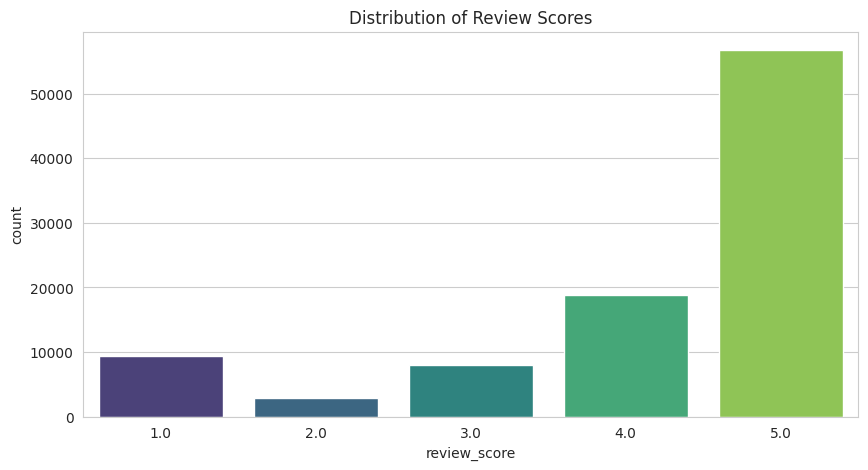

In [5]:
rs = master[(master['order_status'] == 'delivered') & (master['review_score'].notna())].copy()
rs['good_review'] = (rs['review_score'] >= 4).astype(int)

print(rs['good_review'].value_counts(normalize=True).rename('proportion'))
sns.countplot(data=rs, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores')
plt.show()

In [6]:
rs_features_num = [
    'delivery_days', 'estimated_delivery_days', 'delay_days', 'is_late',
    'approval_hours', 'shipping_days', 'n_items', 'n_sellers', 'total_price',
    'total_freight', 'avg_item_price', 'total_payment_value', 'max_installments',
    'product_weight_g', 'product_photos_qty', 'purchase_dow', 'purchase_month',
    'is_weekend_purchase', 'same_state'
]
rs_features_cat = ['product_category_name_english', 'payment_type']

rs_model_df = rs[rs_features_num + rs_features_cat + ['good_review']].copy()
rs_model_df = rs_model_df.dropna(subset=['delivery_days', 'delay_days'])  # need actual delivery to know outcome

for c in rs_features_num:
    rs_model_df[c] = rs_model_df[c].fillna(rs_model_df[c].median())
for c in rs_features_cat:
    rs_model_df[c] = rs_model_df[c].fillna('unknown')

# One-hot encode low-cardinality categoricals, frequency-encode the high-cardinality category
rs_model_df['payment_type'] = rs_model_df['payment_type'].astype('category')
top_categories = rs_model_df['product_category_name_english'].value_counts().nlargest(15).index
rs_model_df['product_category_grouped'] = np.where(
    rs_model_df['product_category_name_english'].isin(top_categories),
    rs_model_df['product_category_name_english'], 'other'
)

X_rs = pd.get_dummies(rs_model_df.drop(columns=['good_review', 'product_category_name_english']),
                       columns=['payment_type', 'product_category_grouped'], drop_first=True)
y_rs = rs_model_df['good_review']

print(X_rs.shape, y_rs.shape)

(95824, 38) (95824,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rs, y_rs, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rs
)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                                 class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf_clf)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f'--- {name} ---')
    print(f"Accuracy : {accuracy_score(y_test, pred):.3f}")
    print(f"Precision: {precision_score(y_test, pred):.3f}")
    print(f"Recall   : {recall_score(y_test, pred):.3f}")
    print(f"F1       : {f1_score(y_test, pred):.3f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, proba):.3f}")
    print()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression ---
Accuracy : 0.716
Precision: 0.860
Recall   : 0.765
F1       : 0.810
ROC AUC  : 0.696



--- Random Forest ---
Accuracy : 0.769
Precision: 0.854
Recall   : 0.853
F1       : 0.853
ROC AUC  : 0.714



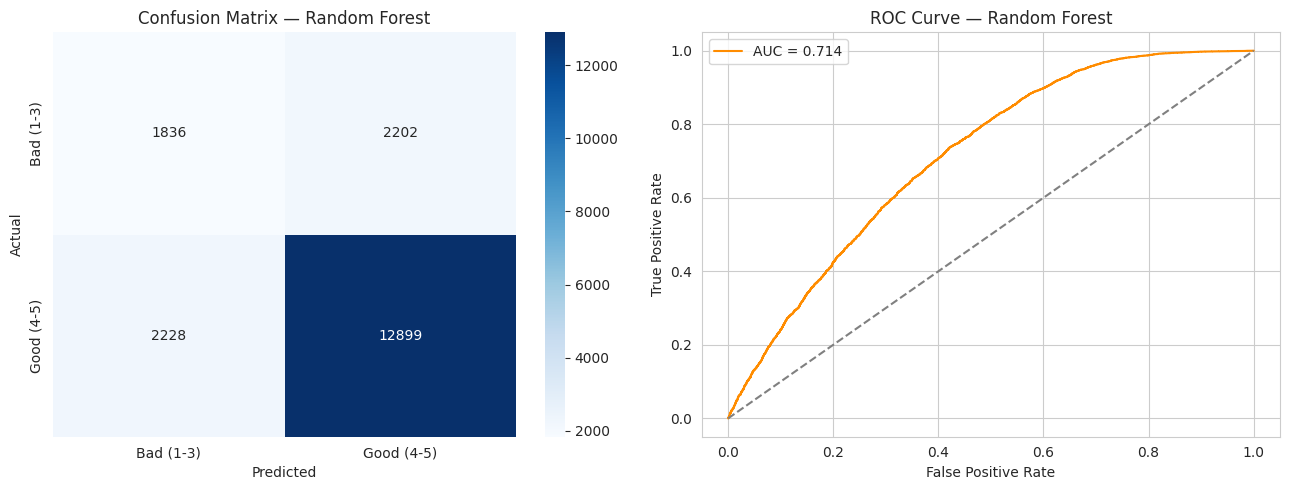

In [8]:
# Confusion matrix + ROC curve for the Random Forest (best-performing model)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Bad (1-3)', 'Good (4-5)'], yticklabels=['Bad (1-3)', 'Good (4-5)'])
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, rf_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, rf_proba):.3f}", color='darkorange')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_476/875230242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


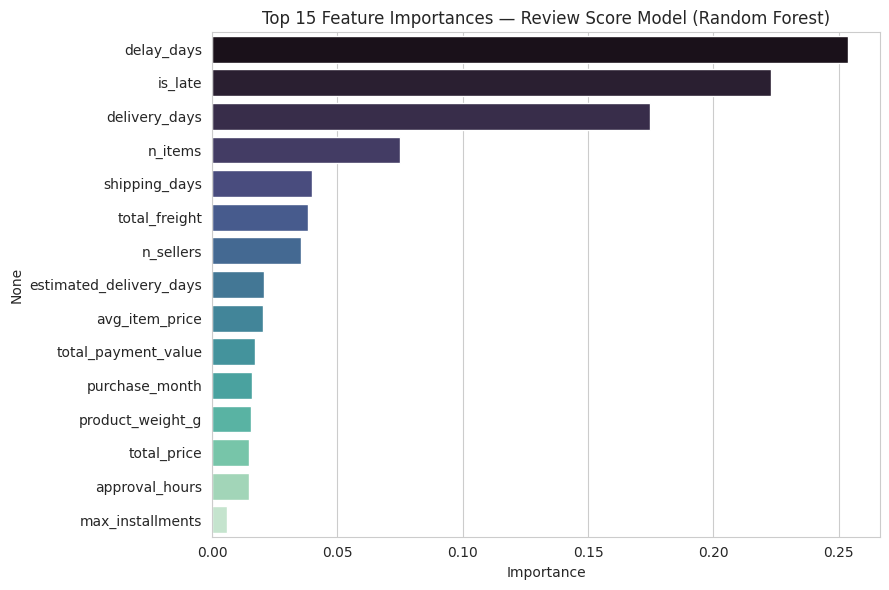

delay_days                 0.253719
is_late                    0.222884
delivery_days              0.174501
n_items                    0.074904
shipping_days              0.039687
total_freight              0.038372
n_sellers                  0.035628
estimated_delivery_days    0.020888
avg_item_price             0.020419
total_payment_value        0.017032
purchase_month             0.015815
product_weight_g           0.015654
total_price                0.014851
approval_hours             0.014780
max_installments           0.005804
dtype: float64

In [9]:
# Feature importance
importances = pd.Series(rf_clf.feature_importances_, index=X_rs.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Top 15 Feature Importances — Review Score Model (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances

**Takeaway:** `is_late` / `delay_days` and `delivery_days` typically dominate — how the delivery experience
went is the single biggest driver of whether a customer leaves a good review. This motivates Model 2 below:
if we can predict delay *before* it happens, we can intervene (e.g. proactive customer communication) and
protect review scores.

## 3. Model 2 — Delivery Delay Prediction

**Business question:** at the time an order is placed (or shortly after), will it ultimately arrive **late**
(after `order_estimated_delivery_date`)?

To make this realistic, we only use features that are known **before/at purchase time or shortly after** —
we deliberately exclude `delivery_days` and `delay_days` themselves (those are only known *after* the delivery
already happened, so including them would leak the answer).


is_late
0    0.932275
1    0.067725
Name: proportion, dtype: float64


/tmp/ipykernel_476/3392174433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dd, x='is_late', palette='rocket')


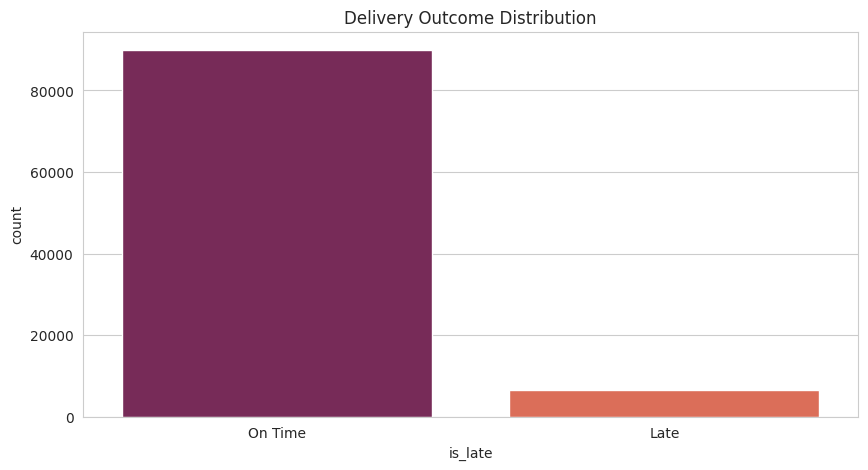

In [10]:
dd = master[master['order_status'] == 'delivered'].copy()
dd = dd.dropna(subset=['is_late', 'estimated_delivery_days'])
dd['is_late'] = dd['is_late'].astype(int)

print(dd['is_late'].value_counts(normalize=True).rename('proportion'))
sns.countplot(data=dd, x='is_late', palette='rocket')
plt.xticks([0, 1], ['On Time', 'Late'])
plt.title('Delivery Outcome Distribution')
plt.show()

In [11]:
dd_features_num = [
    'estimated_delivery_days', 'n_items', 'n_sellers', 'n_products', 'total_price',
    'total_freight', 'avg_item_price', 'total_payment_value', 'max_installments',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'purchase_dow', 'purchase_month', 'purchase_hour', 'is_weekend_purchase', 'same_state'
]
dd_features_cat = ['product_category_name_english', 'payment_type', 'customer_state', 'seller_state']

dd_model_df = dd[dd_features_num + dd_features_cat + ['is_late']].copy()

for c in dd_features_num:
    dd_model_df[c] = dd_model_df[c].fillna(dd_model_df[c].median())
for c in dd_features_cat:
    dd_model_df[c] = dd_model_df[c].fillna('unknown')

top_cat = dd_model_df['product_category_name_english'].value_counts().nlargest(15).index
dd_model_df['product_category_grouped'] = np.where(
    dd_model_df['product_category_name_english'].isin(top_cat),
    dd_model_df['product_category_name_english'], 'other')

top_cust_state = dd_model_df['customer_state'].value_counts().nlargest(10).index
dd_model_df['customer_state_grouped'] = np.where(
    dd_model_df['customer_state'].isin(top_cust_state), dd_model_df['customer_state'], 'other')

X_dd = pd.get_dummies(
    dd_model_df.drop(columns=['is_late', 'product_category_name_english', 'customer_state']),
    columns=['payment_type', 'product_category_grouped', 'customer_state_grouped', 'seller_state'],
    drop_first=True
)
y_dd = dd_model_df['is_late']
print(X_dd.shape, y_dd.shape)

(96478, 68) (96478,)


In [12]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dd, y_dd, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dd
)

rf_delay = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=15,
                                   class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_delay.fit(Xd_train, yd_train)

pred_d = rf_delay.predict(Xd_test)
proba_d = rf_delay.predict_proba(Xd_test)[:, 1]

print("Accuracy :", round(accuracy_score(yd_test, pred_d), 3))
print("Precision:", round(precision_score(yd_test, pred_d), 3))
print("Recall   :", round(recall_score(yd_test, pred_d), 3))
print("F1       :", round(f1_score(yd_test, pred_d), 3))
print("ROC AUC  :", round(roc_auc_score(yd_test, proba_d), 3))
print()
print(classification_report(yd_test, pred_d, target_names=['On Time', 'Late']))

Accuracy : 0.811
Precision: 0.19
Recall   : 0.546
F1       : 0.282
ROC AUC  : 0.772

              precision    recall  f1-score   support

     On Time       0.96      0.83      0.89     17989
        Late       0.19      0.55      0.28      1307

    accuracy                           0.81     19296
   macro avg       0.58      0.69      0.59     19296
weighted avg       0.91      0.81      0.85     19296



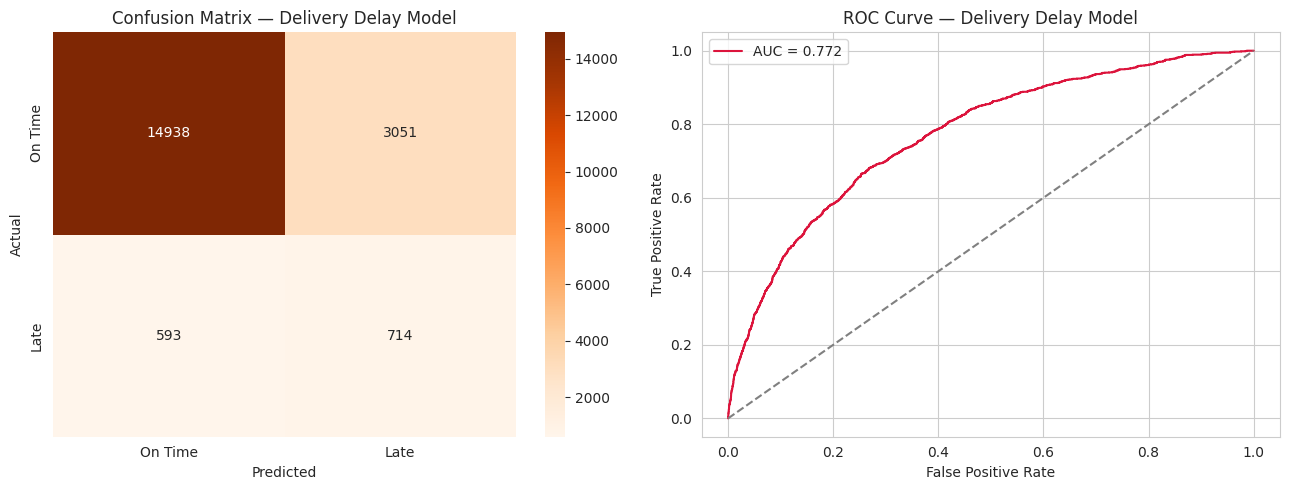

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_d = confusion_matrix(yd_test, pred_d)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['On Time', 'Late'], yticklabels=['On Time', 'Late'])
axes[0].set_title('Confusion Matrix — Delivery Delay Model')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr_d, tpr_d, _ = roc_curve(yd_test, proba_d)
axes[1].plot(fpr_d, tpr_d, label=f"AUC = {roc_auc_score(yd_test, proba_d):.3f}", color='crimson')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Delivery Delay Model')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_476/1836845840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_d.values, y=imp_d.index, palette='flare')


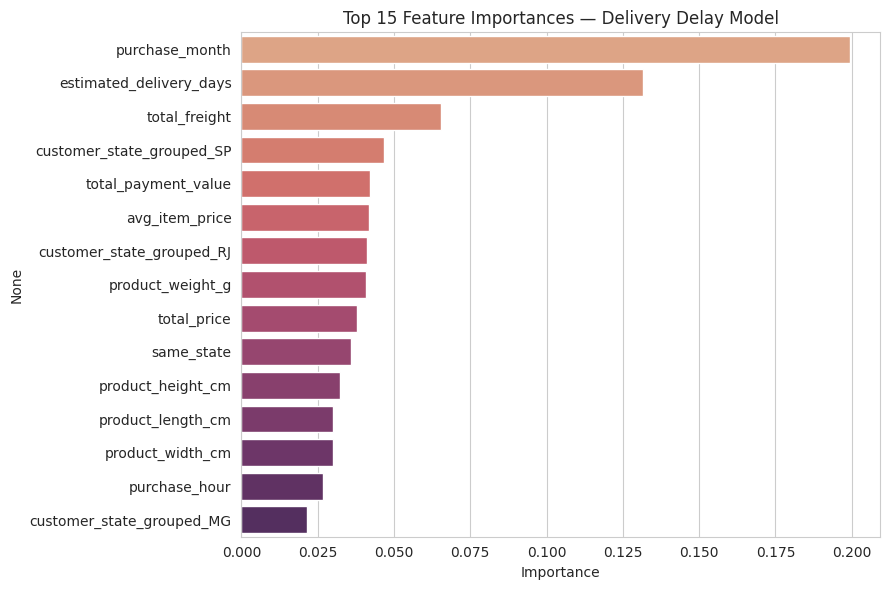

purchase_month               0.199310
estimated_delivery_days      0.131762
total_freight                0.065448
customer_state_grouped_SP    0.046680
total_payment_value          0.042176
avg_item_price               0.041693
customer_state_grouped_RJ    0.041193
product_weight_g             0.040704
total_price                  0.037906
same_state                   0.035909
product_height_cm            0.032160
product_length_cm            0.030082
product_width_cm             0.029956
purchase_hour                0.026843
customer_state_grouped_MG    0.021598
dtype: float64

In [14]:
imp_d = pd.Series(rf_delay.feature_importances_, index=X_dd.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=imp_d.values, y=imp_d.index, palette='flare')
plt.title('Top 15 Feature Importances — Delivery Delay Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
imp_d

## 4. Model 3 — Daily Orders Forecasting

**Business question:** how many orders will be placed on a given day? This extends the simple linear-trend
approach into a proper train/test evaluation and compares it against tree-based models that can pick up
weekly seasonality (day-of-week effects) and other patterns that a straight line cannot.


In [15]:
daily_orders = (orders.groupby(orders['order_purchase_timestamp'].dt.date)
                .size().reset_index(name='order_count')
                .rename(columns={'order_purchase_timestamp': 'day'}))
daily_orders['day'] = pd.to_datetime(daily_orders['day'])
daily_orders = daily_orders.sort_values('day').reset_index(drop=True)

# Drop the extreme launch ramp-up period / any trailing partial day for a cleaner trend if needed
print(daily_orders.shape)
daily_orders.head()

(634, 2)


,day,order_count
0,2016-09-04,1
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,1
4,2016-10-02,1


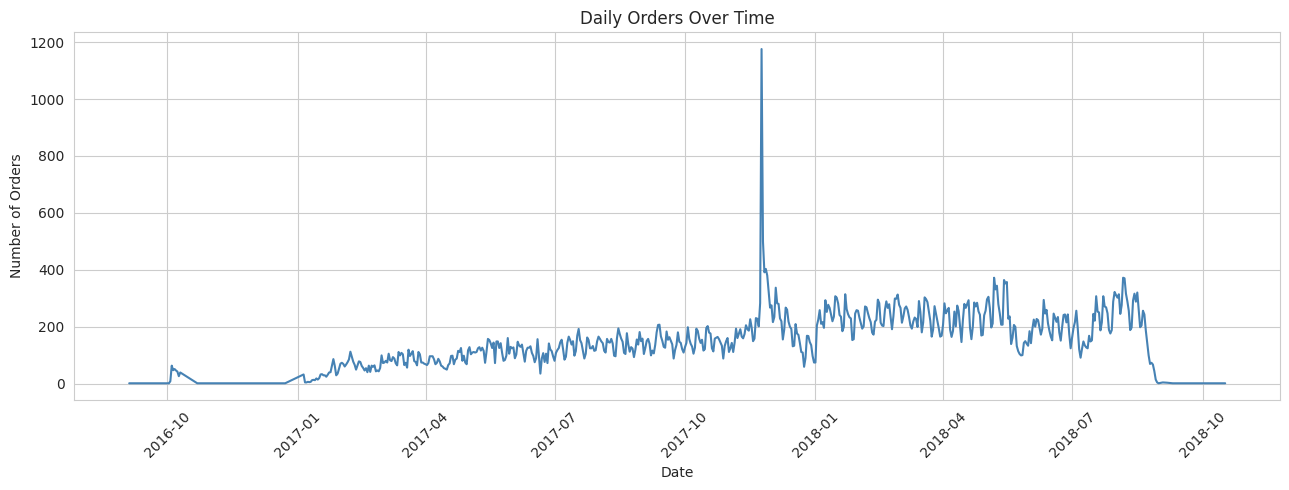

In [16]:
plt.figure(figsize=(13, 5))
plt.plot(daily_orders['day'], daily_orders['order_count'], color='steelblue')
plt.title('Daily Orders Over Time')
plt.xlabel('Date'); plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Feature engineering for time series regression
do = daily_orders.copy()
do['day_numeric'] = (do['day'] - do['day'].min()).dt.days
do['day_of_week'] = do['day'].dt.dayofweek
do['month'] = do['day'].dt.month
do['is_weekend'] = do['day_of_week'].isin([5, 6]).astype(int)
do['day_of_year'] = do['day'].dt.dayofyear

# Lag features (yesterday's and last week's order count) help tree models capture momentum
do['lag_1'] = do['order_count'].shift(1)
do['lag_7'] = do['order_count'].shift(7)
do['rolling_mean_7'] = do['order_count'].shift(1).rolling(7).mean()
do = do.dropna().reset_index(drop=True)

feature_cols = ['day_numeric', 'day_of_week', 'month', 'is_weekend', 'day_of_year',
                 'lag_1', 'lag_7', 'rolling_mean_7']
X_ts = do[feature_cols]
y_ts = do['order_count']

# Time-based split: train on the earlier ~80% of days, test on the most recent ~20%
split_idx = int(len(do) * 0.8)
X_ts_train, X_ts_test = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_ts_train, y_ts_test = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]
train_days, test_days = do['day'].iloc[:split_idx], do['day'].iloc[split_idx:]

print('train:', X_ts_train.shape, 'test:', X_ts_test.shape)

train: (501, 8) test: (126, 8)


In [18]:
# Baseline: simple linear trend (day_numeric only), as in the original snippet
lin_simple = LinearRegression()
lin_simple.fit(X_ts_train[['day_numeric']], y_ts_train)
pred_lin_simple = lin_simple.predict(X_ts_test[['day_numeric']])

# Linear regression with the full feature set
lin_full = LinearRegression()
lin_full.fit(X_ts_train, y_ts_train)
pred_lin_full = lin_full.predict(X_ts_test)

# Random Forest regressor
rf_ts = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_ts.fit(X_ts_train, y_ts_train)
pred_rf_ts = rf_ts.predict(X_ts_test)

# Gradient Boosting regressor
gb_ts = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                   random_state=RANDOM_STATE)
gb_ts.fit(X_ts_train, y_ts_train)
pred_gb_ts = gb_ts.predict(X_ts_test)

results = {}
for name, pred in [('Linear (trend only)', pred_lin_simple),
                    ('Linear (full features)', pred_lin_full),
                    ('Random Forest', pred_rf_ts),
                    ('Gradient Boosting', pred_gb_ts)]:
    mae = mean_absolute_error(y_ts_test, pred)
    rmse = np.sqrt(mean_squared_error(y_ts_test, pred))
    r2 = r2_score(y_ts_test, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Linear (trend only),125.863,159.629,-1.636
Linear (full features),51.538,63.323,0.585
Random Forest,45.791,57.189,0.662
Gradient Boosting,74.235,94.498,0.076


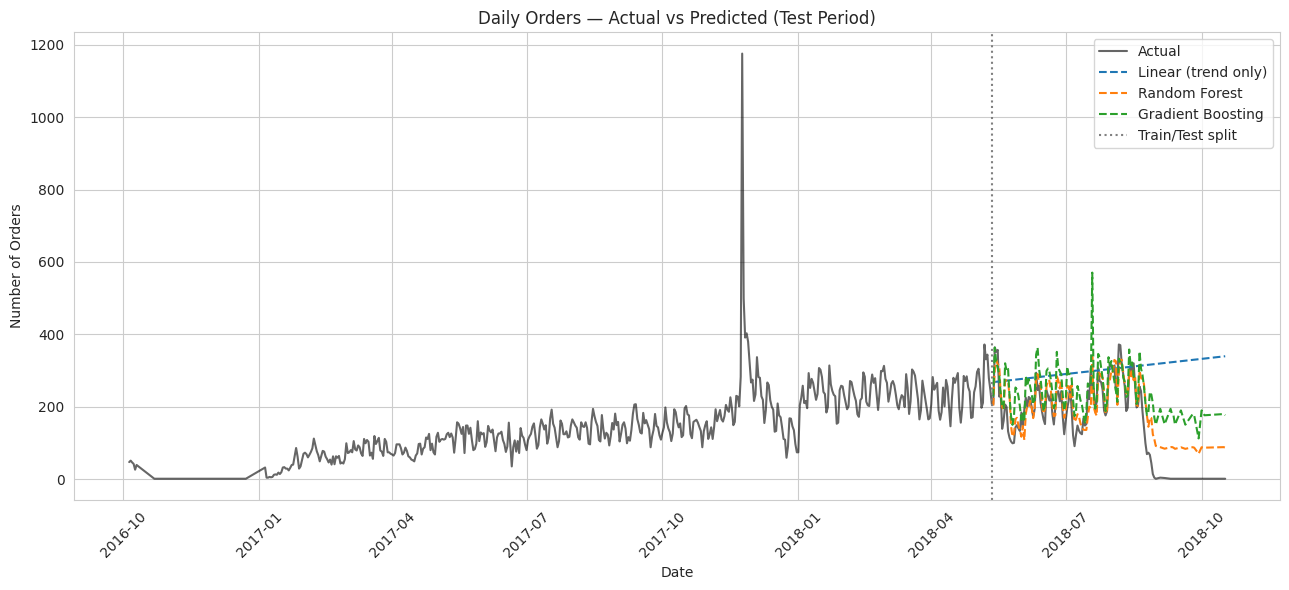

In [19]:
plt.figure(figsize=(13, 6))
plt.plot(do['day'], do['order_count'], label='Actual', color='black', alpha=0.6)
plt.plot(test_days, pred_lin_simple, label='Linear (trend only)', linestyle='--')
plt.plot(test_days, pred_rf_ts, label='Random Forest', linestyle='--')
plt.plot(test_days, pred_gb_ts, label='Gradient Boosting', linestyle='--')
plt.axvline(train_days.iloc[-1], color='gray', linestyle=':', label='Train/Test split')
plt.title('Daily Orders — Actual vs Predicted (Test Period)')
plt.xlabel('Date'); plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_476/1304661516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_ts.values, y=imp_ts.index, palette='crest')


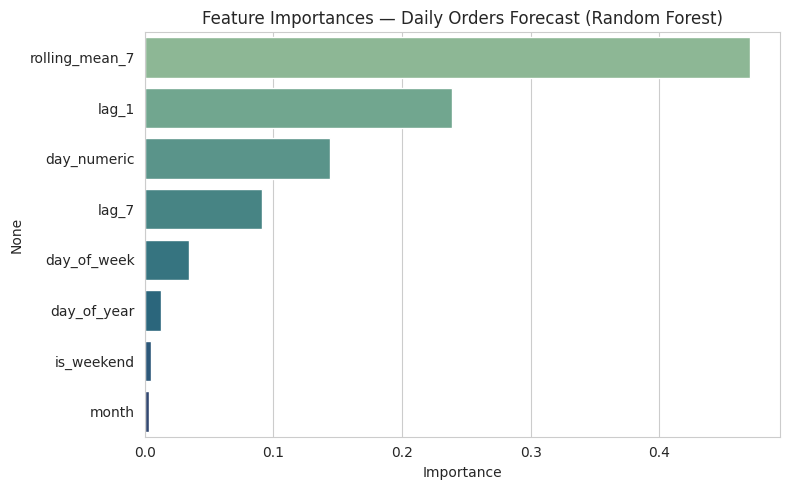

rolling_mean_7    0.470312
lag_1             0.238620
day_numeric       0.144171
lag_7             0.091097
day_of_week       0.034364
day_of_year       0.012995
is_weekend        0.005286
month             0.003154
dtype: float64

In [20]:
imp_ts = pd.Series(rf_ts.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp_ts.values, y=imp_ts.index, palette='crest')
plt.title('Feature Importances — Daily Orders Forecast (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
imp_ts

**Takeaway:** the lag features (`lag_1`, `rolling_mean_7`) and `day_numeric` (overall growth trend) usually
carry the most weight — recent order momentum plus the platform's overall growth trend predict tomorrow's
order volume far better than a single straight-line fit alone.

## 5. Summary

| Model | Type | Target | Best Model | Key Metric |
|---|---|---|---|---|
| 1. Review Score | Binary classification | Good (4–5) vs Bad (1–3) review | Random Forest | ROC AUC (see Section 2) |
| 2. Delivery Delay | Binary classification | Late vs On-time delivery | Random Forest | ROC AUC (see Section 3) |
| 3. Daily Orders | Regression / time series | Orders per day | Random Forest / Gradient Boosting | RMSE, R² (see Section 4) |

**Next steps you could take from here:**
- Tune hyperparameters (`GridSearchCV` / `RandomizedSearchCV`) for each model.
- Try `XGBoost` / `LightGBM` if available in your environment — they often edge out `RandomForest` on tabular data like this.
- For Model 1, experiment with predicting the full 1–5 score (multiclass) instead of the binary good/bad split.
- For Model 3, consider a dedicated time-series library (e.g. `Prophet` or `statsmodels` SARIMAX) to explicitly model yearly seasonality once more history is available.
